In [2]:
import pandas as pd
import matplotlib.pyplot as plt



 Original Bill series:
0    100000.0
1    200000.0
2    300000.0
3    200000.0
4    400000.0
5    600000.0
Name: Bill, dtype: float64

 Original Date series:
0     2025-01-5
1     2025-01-5
2    2025-02-12
3     2025-05-6
4    2025-06-16
5    2025-07-31
Name: Admission_Date, dtype: object

 Fill the Missing Bill value with median before plotting? (yes/no): 


 yes


Convert ADMISSION DATE to DD/MM/YYYY for display? (yes/no):


 yes


0    100000.0
1    200000.0
2    300000.0
3    200000.0
4    400000.0
5    600000.0
Name: Bill, dtype: float64


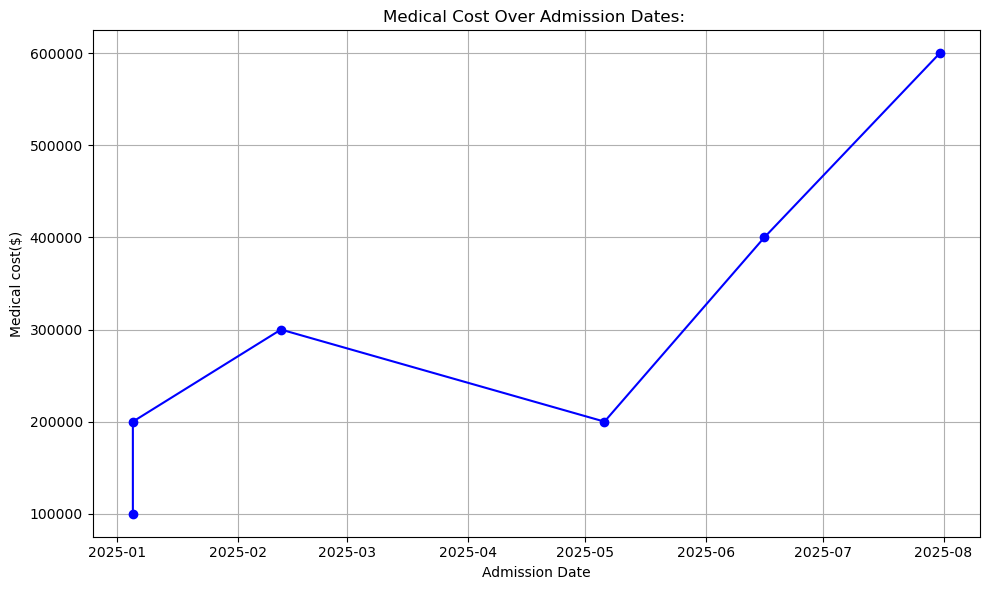

In [ ]:
try:
    df = pd.read_csv('hospital_data_updated1.csv')
    
    cost_series = df["Bill"]
    date_series = df["Admission_Date"]
    print("\n Original Bill series:")
    print(cost_series)
    print("\n Original Date series:")
    print(date_series)

    
    # User input cleaning and plotting

    print("\n Fill the Missing Bill value with median before plotting? (yes/no): ")
    fill_confirm =input().strip().lower()
    print("Convert ADMISSION DATE to DD/MM/YYYY for display? (yes/no):")
    date_format_confirm = input().strip().lower()

    # Perform clean bill missing values
    if fill_confirm == 'yes':
        median_cost = cost_series.median()
        cleaned_cost_series = cost_series.fillna(median_cost)
        print(cleaned_cost_series)
    else:
        print('n No chnages to medical cost:')

    
    # Convert admission date to datetime
    
    cleaned_date_series = pd.to_datetime(date_series, format = '%Y-%m-%d', errors='coerce')
    if date_format_confirm == "yes":
        display_dates = cleaned_date_series.dt.strftime('%d-%m-%Y')
    else:
        display_dates = cleaned_date_series

    
    # plot
    plt.figure(figsize= (10, 6))
    plt.plot(cleaned_date_series, cleaned_cost_series, marker='o', color='blue')
    plt.title("Medical Cost Over Admission Dates: ")
    plt.xlabel("Admission Date")
    plt.ylabel("Medical cost($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Update and save

    if fill_confirm == 'yes':
        df['Bill'] = cleaned_cost_series
        df['Admission_date'] = display_dates if date_format_confirm == 'yes' else cleaned_data_series
        df.to_csv('hospital_data_updated1.csv')
        print("\nUpdated sucessfully")
    else:
        print('\nNot Updated')

except FileNotFoundError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"Error: {e}")